# Real, and worth acting on?

**Week 1, Thursday. Notebook 2 of 3, round 2.** By the end of this notebook you can size a real gap
in rupees three ways, set it against what acting would cost, and keep "significant" and "important"
in two separate sentences.

> **The client asks.** "So my tier really is slipping. What do I get to fix it?"
>
> The head of Retail-Plus, before the growth review

> **Kavya's review, before you start.** "Tell me how big it is in rupees, next to the whole company
> and next to what the fix costs. Then tell me it is real."

Notebook 1 established that the Retail-Plus fall, Rs 1,110 of delivered revenue per member, is
bigger than the usual wobble: 135 of 5,000 shuffles made a fall that large. This notebook asks the
question a budget holder asks next.

**Setup.** The same file and the same three helpers as notebook 1: `member_totals`, `mean` and
`shuffle_gaps`, with `histogram` for many shuffles at once.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import random

ORDERS = kit.load_csv("C2_W01_D04_orders_STUDENT.csv")


def member_totals(segment, quarter):
    """Delivered revenue per member of one segment in one quarter, one number per member."""
    members = sorted({o["customer_id"] for o in ORDERS if o["segment"] == segment})
    totals = {m: 0 for m in members}
    for o in ORDERS:
        if o["segment"] == segment and o["quarter"] == quarter and o["status"] == "delivered":
            totals[o["customer_id"]] += int(o["amount"])
    return [totals[m] for m in members]


def mean(values):
    return sum(values) / len(values)


def shuffle_gaps(q1, q2, times, seed):
    """Deal the pooled values to two piles at random, many times, and keep each gap."""
    random.seed(seed)
    pool = q1 + q2
    gaps = []
    for _ in range(times):
        random.shuffle(pool)
        gaps.append(mean(pool[:len(q1)]) - mean(pool[len(q1):]))
    return gaps


def histogram(gaps, step):
    """Count the gaps in bins of one width, for a columns chart of thousands of shuffles."""
    lo = int(min(gaps) // step) * step
    edges = list(range(lo, int(max(gaps)) + step, step))
    counts = [sum(1 for g in gaps if a <= g < a + step) for a in edges]
    labels = [f"{a + step // 2:,}" for a in edges]
    return labels, counts

plus_q1, plus_q2 = member_totals("Retail-Plus", "Q1"), member_totals("Retail-Plus", "Q2")
plus_gap = mean(plus_q1) - mean(plus_q2)
print(f"{len(plus_q1)} Retail-Plus members; gap Rs {plus_gap:,.0f} per member, carried from notebook 1")

22 Retail-Plus members; gap Rs 1,110 per member, carried from notebook 1


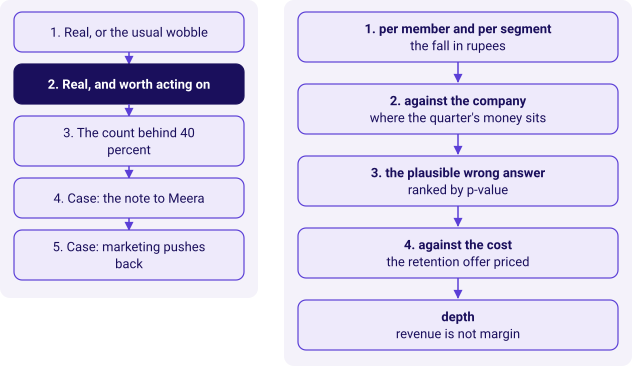

In [2]:
kit.side_by_side(
    kit.ladder(['Real, or the usual wobble', 'Real, and worth acting on', 'The count behind 40 percent', 'Case: the note to Meera', 'Case: marketing pushes back'], lit=1, show=False),
    kit.vflow(["1. per member and per segment\nthe fall in rupees",
               "2. against the company\nwhere the quarter's money sits",
               "3. the plausible wrong answer\nranked by p-value",
               "4. against the cost\nthe retention offer priced",
               "depth\nrevenue is not margin"], show=False),
)

## 1. The fall in rupees, per member and for the segment

A per-member gap is a rate. The budget holder needs the total: the gap times the members who exist in
both quarters, which is the same as the segment's delivered revenue in Q1 less Q2.

**Predict before you run.** Retail-Plus lost Rs 1,110 per member across its members. In total, per
quarter, that is roughly: a) Rs 2,400; b) Rs 24,000; c) Rs 2.4 lakh; d) Rs 24 lakh.

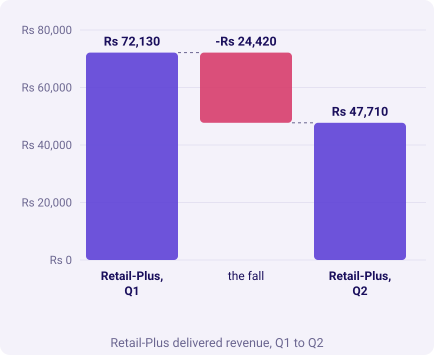

In [3]:
plus_total_q1, plus_total_q2 = sum(plus_q1), sum(plus_q2)
plus_fall = plus_total_q1 - plus_total_q2
kit.bridge(("Retail-Plus, Q1", plus_total_q1), [("the fall", -plus_fall)], end_label="Retail-Plus, Q2",
           title="Retail-Plus delivered revenue, Q1 to Q2")
kit.stats([(kit.rupees(plus_gap), "per member", "Q1 mean less Q2 mean"),
           (f"{len(plus_q1)}", "members", "in both quarters"),
           (kit.rupees(plus_fall), "a quarter", "the segment's fall")])

**What happened.** The answer is b. Rs 1,110 times 22 members is Rs 24,420 a quarter: the segment
delivered Rs 72,130 in Q1 and Rs 47,710 in Q2. For the segment that is a third of its money, which is
why the head of Retail-Plus is worried.

In [4]:
kit.check("the per-member gap times the members is the segment's fall", round(plus_gap * len(plus_q1)) == plus_fall,
          f"{plus_gap:,.0f} x {len(plus_q1)} = {plus_fall:,}")
kit.check("Retail-Plus lost Rs 24,420 of delivered revenue in a quarter", plus_fall == 24420, kit.rupees(plus_fall))
kit.check("that is about a third of the segment's Q1", 0.30 < plus_fall / plus_total_q1 < 0.37,
          f"{plus_fall / plus_total_q1:.1%}")

## 2. Against the company's quarter

A third of a segment is large for the segment. Meera runs the company, so the second size is the fall
against the company's delivered revenue, and the bridge shows every segment's move side by side.

**Predict before you run.** As a share of the company's Q2 delivered revenue, the Retail-Plus fall
is: a) about 30 percent; b) about 3 percent; c) under half of one percent; d) impossible to say
without Business.

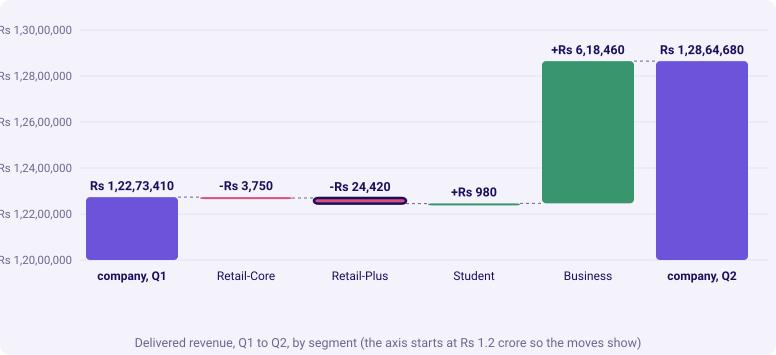

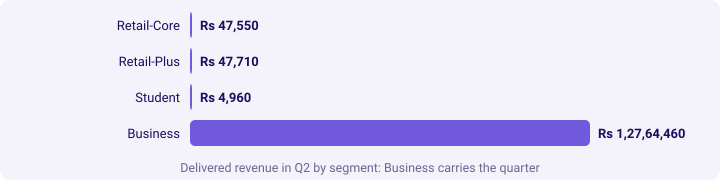

company delivered: Q1 Rs 1,22,73,410, Q2 Rs 1,28,64,680; the Retail-Plus fall is 0.19% of Q2


In [5]:
SEGMENTS = ["Retail-Core", "Retail-Plus", "Student", "Business"]


def delivered(segment, quarter):
    return sum(int(o["amount"]) for o in ORDERS
               if o["segment"] == segment and o["quarter"] == quarter and o["status"] == "delivered")


company_q1 = sum(delivered(s, "Q1") for s in SEGMENTS)
company_q2 = sum(delivered(s, "Q2") for s in SEGMENTS)
moves = [(s, delivered(s, "Q2") - delivered(s, "Q1")) for s in SEGMENTS]
kit.bridge(("company, Q1", company_q1), moves, end_label="company, Q2", lo=12_000_000, lit=[1],
           title="Delivered revenue, Q1 to Q2, by segment (the axis starts at Rs 1.2 crore so the moves show)")
kit.bars([(s, delivered(s, "Q2")) for s in SEGMENTS], fmt=kit.rupees,
         title="Delivered revenue in Q2 by segment: Business carries the quarter")
share_of_company = plus_fall / company_q2
print(f"company delivered: Q1 {kit.rupees(company_q1)}, Q2 {kit.rupees(company_q2)}; "
      f"the Retail-Plus fall is {share_of_company:.2%} of Q2")

**What happened.** The answer is c. The company delivered Rs 1,28,64,680 in Q2, and the Retail-Plus
fall is 0.19 percent of it, less than one rupee in five hundred. Business rose by Rs 6,18,460 in the
same quarter, twenty-five times the Retail-Plus fall. The fall is real and it is small against the
company; both are true, and the note needs both.

In [6]:
kit.check("the bridge lands: Q1 plus every segment's move is Q2", company_q1 + sum(m for _, m in moves) == company_q2)
kit.check("the Retail-Plus fall is under half of one percent of the company's Q2", share_of_company < 0.005,
          f"{share_of_company:.2%}")
kit.check("Business moved more rupees than Retail-Plus", abs(dict(moves)["Business"]) > plus_fall)

## 3. The plausible wrong answer

**The plausible wrong answer.** A hurried draft runs the shuffle on every consumer and Business
segment, sorts by the share, and ranks the smallest share first. Student waits for notebook 3.

In [7]:
ranked = []
for s in ["Retail-Core", "Retail-Plus", "Business"]:
    q1, q2 = member_totals(s, "Q1"), member_totals(s, "Q2")
    gap = mean(q1) - mean(q2)
    gaps = shuffle_gaps(q1, q2, 5000, seed=2026)
    share = sum(1 for g in gaps if g >= gap) / len(gaps)      # a fall at least this large, as in notebook 1
    ranked.append((s, share, sum(q2) - sum(q1)))
ranked.sort(key=lambda r: r[1])
print("The draft ranks by p-value:")
for n, (s, share, move) in enumerate(ranked, 1):
    print(f"  {n}. {s:12s} p = {share:.3f}")
print(f"Draft: '{ranked[0][0]} is our biggest problem; fund its retention programme first.'")

The draft ranks by p-value:
  1. Retail-Plus  p = 0.027
  2. Retail-Core  p = 0.345
  3. Business     p = 0.555
Draft: 'Retail-Plus is our biggest problem; fund its retention programme first.'


**Why it is wrong.** The share says how surely a move beats chance. It never says how big the move
is, and the draft ranked by the wrong column. The check is to put the rupees beside the share, and a
second check shows why the two columns can disagree so far: with enough orders, even a trivial gap
beats chance.

Segment,"p, a fall this large","Delivered revenue, Q2 less Q1"
Retail-Plus,0.027,"-Rs 24,420"
Retail-Core,0.345,"-Rs 3,750"
Business,0.555,"Rs 6,18,460"


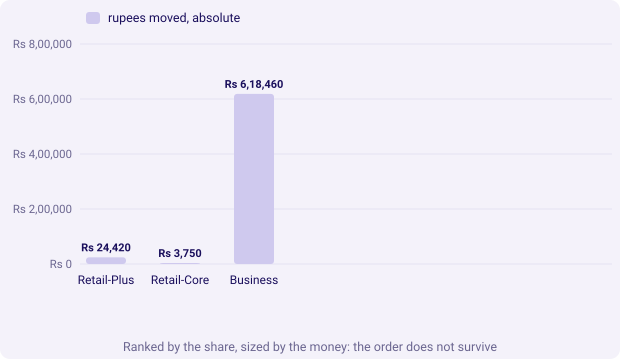

In [8]:
kit.table(["Segment", "p, a fall this large", "Delivered revenue, Q2 less Q1"],
          [(s, f"{share:.3f}", kit.rupees(move)) for s, share, move in ranked],
          caption="The same three segments with the money beside the share")
kit.columns([s for s, _, _ in ranked], [("rupees moved, absolute", [abs(m) for _, _, m in ranked])],
            fmt=kit.rupees, width=620, title="Ranked by the share, sized by the money: the order does not survive")

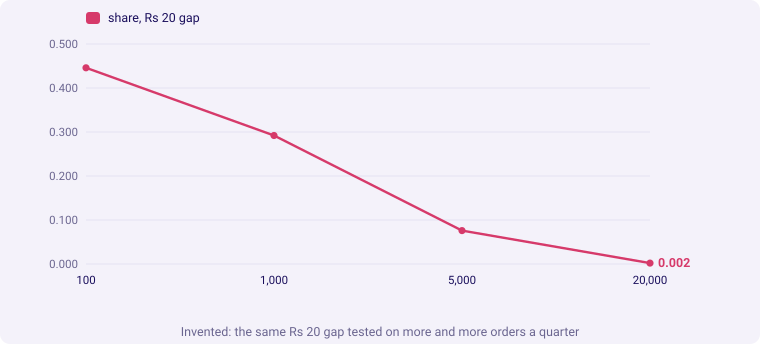

{100: 0.446, 1000: 0.292, 5000: 0.076, 20000: 0.002}


In [9]:
# Invented orders: a Rs 20 gap on orders of Rs 1,000 to Rs 3,400, the same gap at every size.
maker = random.Random(11)
base = [maker.randint(1000, 3400) for _ in range(20000)]
sizes, shares = [100, 1000, 5000, 20000], []
for n in sizes:
    q2 = base[:n]
    q1 = [v + 20 for v in q2]
    gaps = shuffle_gaps(q1, q2, 500, seed=2026)
    shares.append(sum(1 for g in gaps if g >= 20) / len(gaps))
kit.line([f"{n:,}" for n in sizes], [("share, Rs 20 gap", shares, "bad")], fmt=lambda v: f"{v:.3f}",
         title="Invented: the same Rs 20 gap tested on more and more orders a quarter")
print(dict(zip(sizes, shares)))

The invented gap never changes, and its share falls from 0.45 on a hundred orders to 0.002 on twenty
thousand. A big enough sample makes a trivial gap "significant". That is why size is its own
measurement.

**The fix.** Two sentences where the draft had one, and the ranking done by money:

In [10]:
line_real = "The Retail-Plus fall is larger than the usual wobble."
line_size = (f"It is worth {kit.rupees(plus_fall)} a quarter, {share_of_company:.2%} of the company's "
             f"delivered revenue, while Business moved {kit.rupees(dict(moves)['Business'])} the same quarter.")
print(line_real)
print(line_size)
kit.check("the smallest share and the biggest money are different segments",
          ranked[0][0] != max(ranked, key=lambda r: abs(r[2]))[0])
kit.check("an invented Rs 20 gap goes from chance-sized to significant on sample size alone",
          shares[0] > 0.2 and shares[-1] < 0.01, f"{shares}")

The Retail-Plus fall is larger than the usual wobble.
It is worth Rs 24,420 a quarter, 0.19% of the company's delivered revenue, while Business moved Rs 6,18,460 the same quarter.


What changed: the ranking. By share, Retail-Plus came first; by rupees, it sits well behind Business,
and the retention programme has to justify itself against Rs 24,420 a quarter, not against a p-value.

## 4. Against the cost: the retention offer priced

The head of Retail-Plus proposes a retention offer. **The cost is an assumption for this exercise,
since no Kalpa figure exists for it:** Rs 500 per member per quarter, offered to all 22 members.

**Predict before you run.** What share of the Rs 24,420 fall would the offer have to win back just to
pay for itself in revenue? a) all of it; b) about 45 percent; c) about 5 percent; d) none, since any
recovery is a gain.

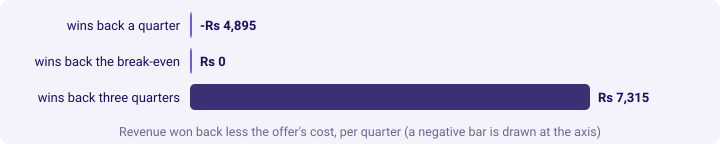

offer cost Rs 11,000 a quarter; break-even recovery 45% of the fall
  wins back a quarter        net -Rs 4,895
  wins back the break-even   net Rs 0
  wins back three quarters   net Rs 7,315


In [11]:
offer_per_member = 500                                   # assumed for the exercise
offer_cost = offer_per_member * len(plus_q1)
break_even = offer_cost / plus_fall
scenarios = [("wins back a quarter", 0.25), ("wins back the break-even", break_even),
             ("wins back three quarters", 0.75)]
kit.bars([(label, round(plus_fall * r - offer_cost)) for label, r in scenarios], fmt=kit.rupees,
         lit=[2], title="Revenue won back less the offer's cost, per quarter (a negative bar is drawn at the axis)")
print(f"offer cost {kit.rupees(offer_cost)} a quarter; break-even recovery {break_even:.0%} of the fall")
for label, r in scenarios:
    print(f"  {label:26s} net {kit.rupees(round(plus_fall * r - offer_cost))}")

**What happened.** The answer is b. The offer costs Rs 11,000 a quarter, so it has to win back 45
percent of the fall before it breaks even on revenue. Winning back a quarter of the fall loses about
Rs 4,900; winning back three quarters gains about Rs 7,300. The decision rests on a recovery rate
nobody has measured, which is exactly what the note should say.

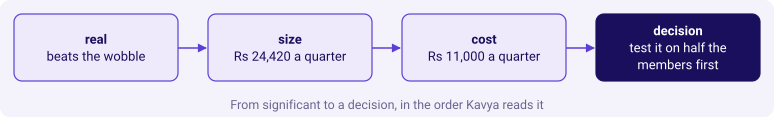

In [12]:
kit.check("the offer costs Rs 11,000 a quarter", offer_cost == 11000, kit.rupees(offer_cost))
kit.check("it pays only above a 45 percent recovery", round(break_even, 2) == 0.45, f"{break_even:.3f}")
kit.flow(["real\nbeats the wobble", "size\nRs 24,420 a quarter", "cost\nRs 11,000 a quarter",
          "decision\ntest it on half the members first"], lit=3,
         title="From significant to a decision, in the order Kavya reads it")

A range, named once: the Rs 1,110 per member is one estimate from 22 members, so the true fall could
be somewhat larger or smaller. The range of sizes the data supports is called a **confidence
interval**; building one comes in a later week, and today the name is enough.

> **Kavya's review.** "Real, yes. Worth Rs 24,420 a quarter, which is small against Business and a
> third of the tier. The offer pays only if it wins back 45 percent, so do not fund it for all 22:
> offer it to half, hold back half, and measure. That is a watch item with a test attached, never a
> budget line."

### In the interview

**[F] A metric moved and the test says significant; how do you decide whether the business should
act?** "Significant only tells me the move is bigger than noise. To act I need three more things:
the size in money, against the whole business and against the segment; the cost of the action; and
how much of the gap the action would plausibly recover. If the break-even recovery is higher than
anything we have seen, I recommend a small test with a held-back group rather than a rollout." The
interviewer wants the separation of significance from size, a cost, and a way to learn cheaply.

**[S] Explain a finding to a non-technical stakeholder.** "I lead with the decision the finding
supports, in one sentence, with one number and its denominator. Then the evidence, then the caveat
that would change my view, then the action and what it costs. For example: Retail-Plus really is
spending less, about Rs 24,000 a quarter, which is a third of the tier and a fifth of one percent of
the company; a retention offer pays only if it wins back 45 percent, so test it on half the members
first." The interviewer is listening for the order, one number with its base, and no jargon.

### Depth: revenue is not margin

The break-even above compares the offer with revenue won back. Kalpa keeps only its margin on that
revenue, so the true break-even is higher. **The margin below is an assumption for the depth
section, since no Kalpa margin figure exists:** at a 30 percent gross margin, the offer would have to
win back more than the whole fall.

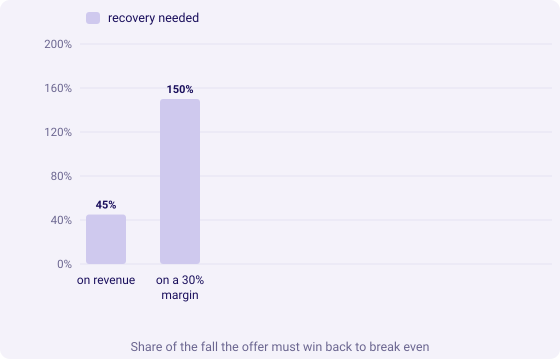

In [13]:
assumed_margin = 0.30                                    # assumed; no Kalpa figure exists
margin_break_even = offer_cost / (plus_fall * assumed_margin)
kit.columns(["on revenue", "on a 30% margin"], [("recovery needed", [round(break_even * 100), round(margin_break_even * 100)])],
            fmt=lambda v: f"{v:.0f}%", width=560, title="Share of the fall the offer must win back to break even")
kit.check("on an assumed 30 percent margin the offer cannot pay back from this fall", margin_break_even > 1,
          f"{margin_break_even:.0%}")

In [14]:
kit.check_summary()
print("Next: notebook 3. Student is up 40 percent; how many orders stand behind it?")

Next: notebook 3. Student is up 40 percent; how many orders stand behind it?
